
# Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

## Objectives:
1. Perform descriptive analytics for numerical columns.
2. Visualize distributions and relationships using plots.
3. Standardize numerical variables (z-score normalization).
4. Convert categorical variables into dummy variables (one-hot encoding).


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying plots inline
%matplotlib inline


In [2]:

# Load dataset
df = pd.read_csv("/content/sales_data_with_discounts.csv")

# Show basic info
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


## Descriptive Analytics for Numerical Columns

In [3]:

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Descriptive stats: mean, median, std, mode
desc_stats = df[num_cols].agg(['mean', 'median', 'std']).transpose()
desc_stats['mode'] = df[num_cols].mode().iloc[0]
desc_stats


,mean,median,std,mode
Volume,5.066667,4.000000,4.231602,3.000000
Avg Price,10453.433333,1450.000000,18079.904840,400.000000
Total Sales Value,33812.835556,5700.000000,50535.074173,24300.000000
Discount Rate (%),15.155242,16.577766,4.220602,5.007822
Discount Amount,3346.499424,988.933733,4509.902963,69.177942
Net Sales Value,30466.336131,4677.788059,46358.656624,326.974801


## Data Visualization

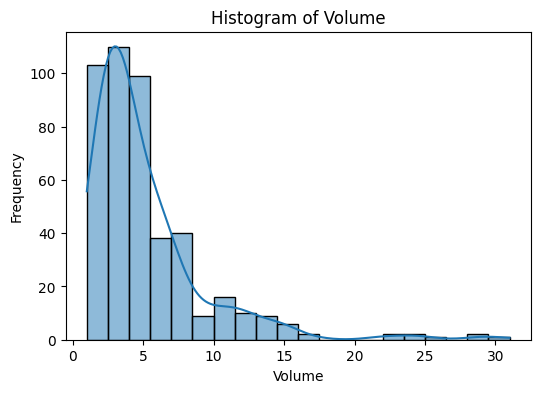

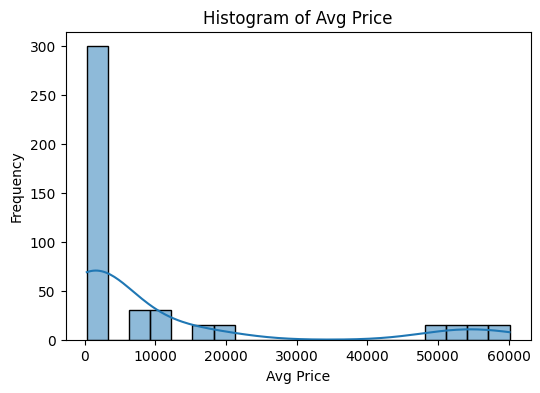

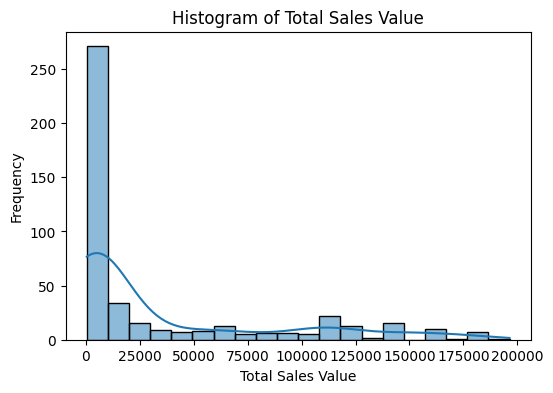

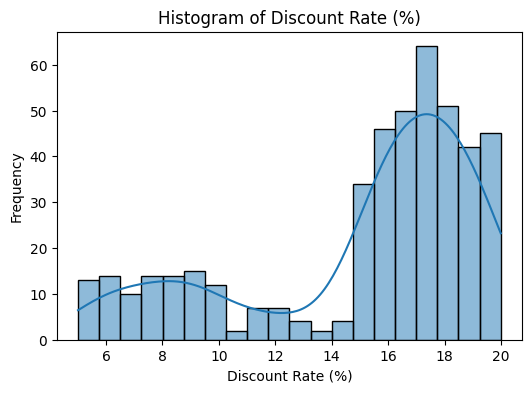

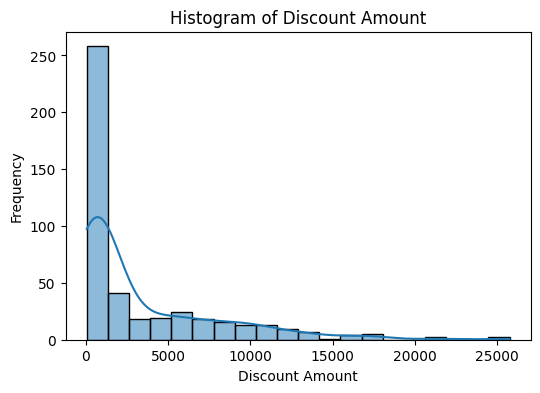

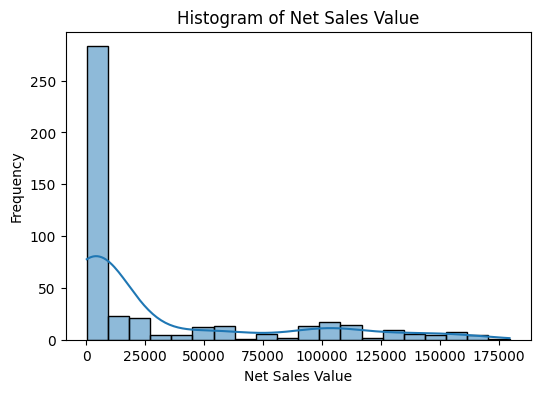

In [4]:
# Histograms
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

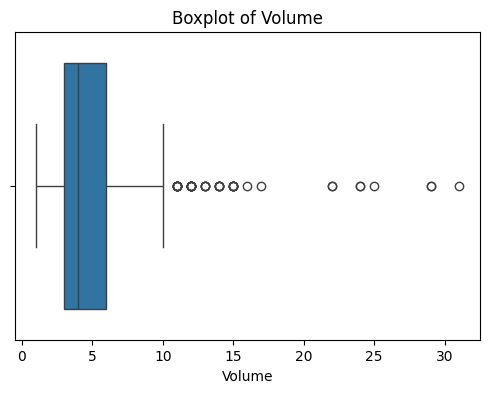

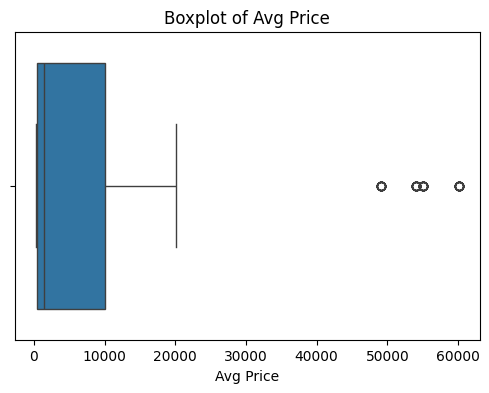

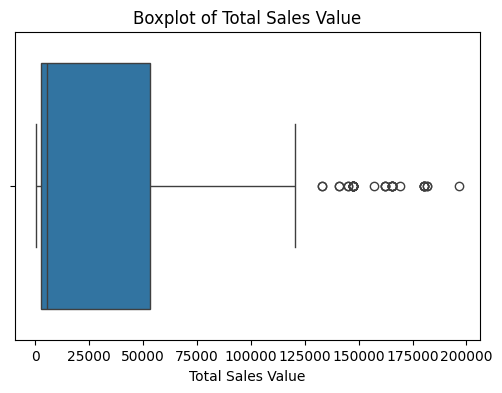

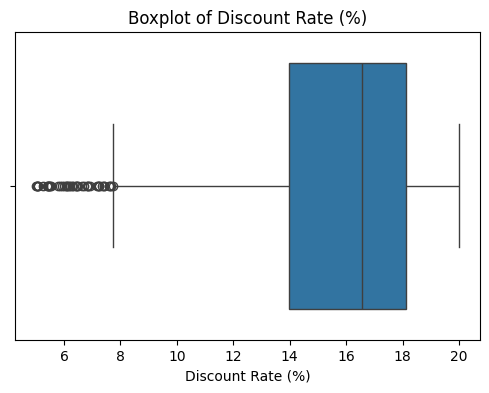

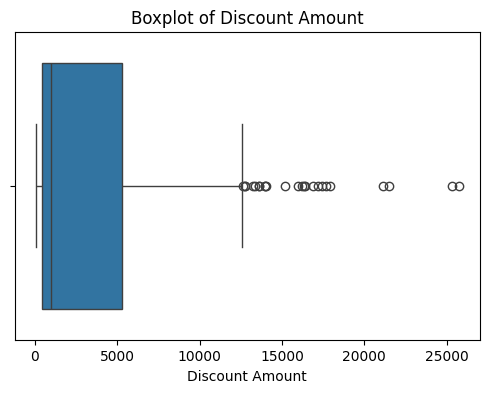

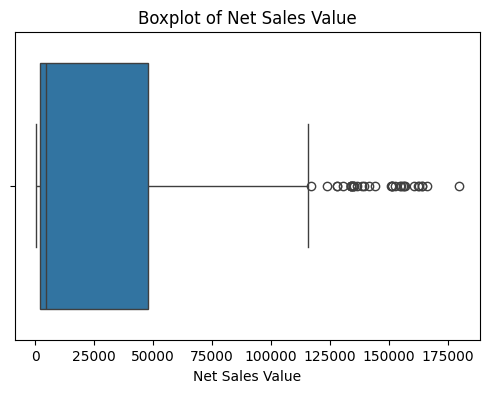

In [5]:
# Boxplots
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

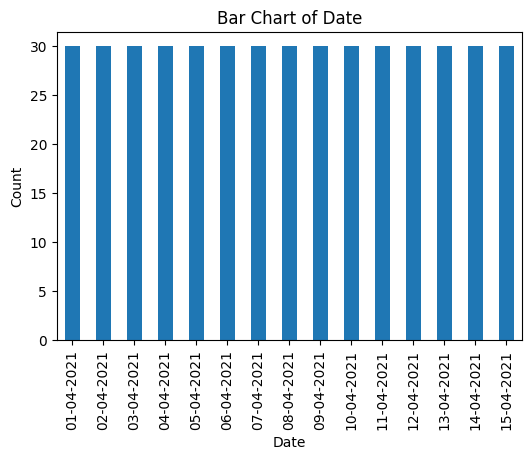

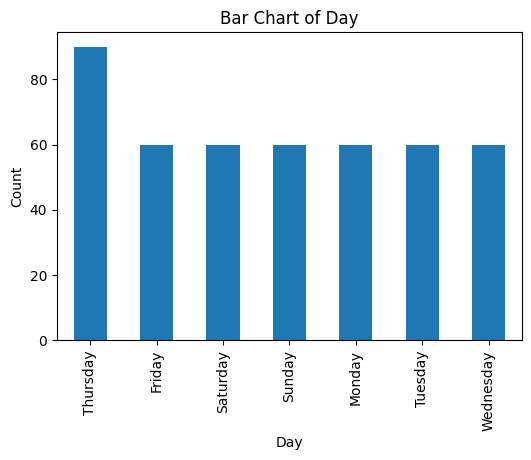

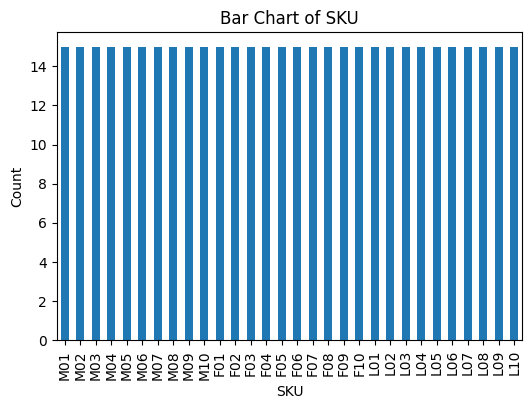

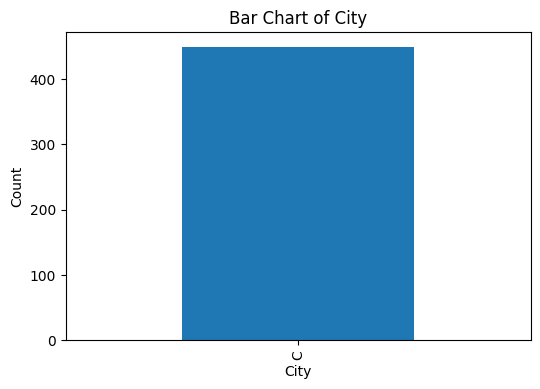

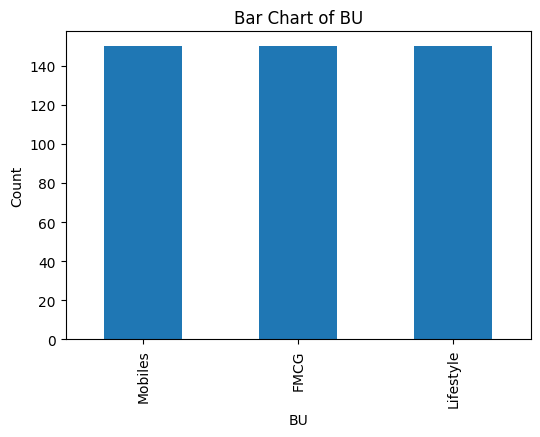

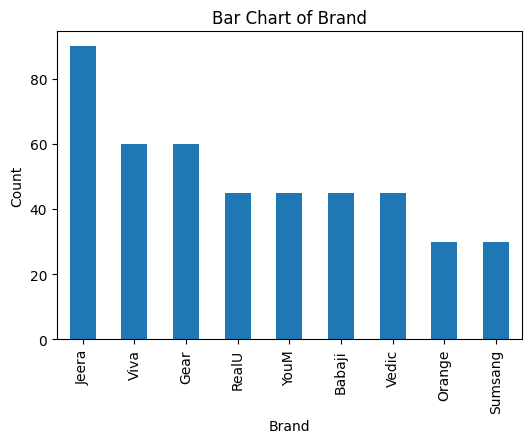

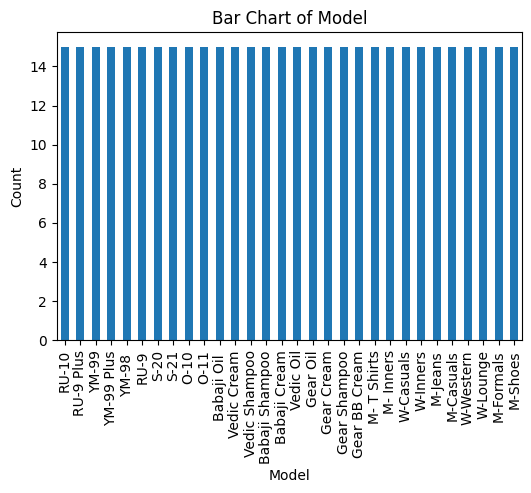

In [6]:
# Bar charts for categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## Standardization of Numerical Variables

In [7]:

# Z-score standardization
df_standardized = df.copy()
df_standardized[num_cols] = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()

df_standardized[num_cols].head()


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,2.347417,0.091072,2.922469,-0.829365,3.948422,2.801638
1,1.165831,-0.019548,1.329516,-0.851714,1.846958,1.269613
2,0.456880,0.312312,1.561038,-1.350129,1.621190,1.543957
3,0.220563,0.533552,1.717365,-1.947555,1.112568,1.763847
4,-0.488389,-0.130168,-0.188242,0.672990,0.227598,-0.227342


## Conversion of Categorical Data into Dummy Variables

In [8]:
# One-hot encoding
df_encoded = pd.get_dummies(df_standardized, columns=cat_cols, drop_first=True)

df_encoded.head()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,Date_05-04-2021,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,2.347417,0.091072,2.922469,-0.829365,3.948422,2.801638,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.165831,-0.019548,1.329516,-0.851714,1.846958,1.269613,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.456880,0.312312,1.561038,-1.350129,1.621190,1.543957,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,0.220563,0.533552,1.717365,-1.947555,1.112568,1.763847,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,-0.488389,-0.130168,-0.188242,0.672990,0.227598,-0.227342,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False



## 📝 Conclusion

- Descriptive analytics showed that sales and discounts are highly skewed with outliers.
- Visualizations highlighted skewed distributions and categorical dominance of some brands/models.
- Standardization ensured uniform scaling of numerical columns.
- One-hot encoding transformed categorical variables into a machine-learning-friendly format.

These preprocessing steps are crucial for building reliable predictive models.
